# LAB ASSIGNMENT 5: Taxi Route Optimization using Q-Learning
**Objective:** Train an RL agent to navigate a 5x5 grid, pick up a passenger, and drop them off optimally.

* # Select: Taxi Route Optimization
* # Algorithm: Q-Learning
* # Language: Python + Gymnasium



### Install Required Libraries



In [27]:
!pip install gymnasium numpy matplotlib

### Step 1: Import Required Libraries

In [28]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time

### Step 2: Initialize Environment and Q-Table
We use the `Taxi-v4` environment from Gymnasium.
- **States:** 500 discrete states
- **Actions:** 6 discrete actions (4 moves, pickup, dropoff)

In [29]:
# Create the Taxi environment
env = gym.make('Taxi-v4')

# Get state and action sizes
state_size = env.observation_space.n
action_size = env.action_space.n

print(f"Number of States: {state_size}")
print(f"Number of Actions: {action_size}")

# Initialize Q-table with zeros
q_table = np.zeros((state_size, action_size))

Number of States: 500
Number of Actions: 6


### Step 3: Set Training Hyperparameters

In [30]:
# Training parameters
episodes = 5000
alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor
epsilon = 1.0        # Exploration rate
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005

rewards_all_episodes = []

### Step 4: The Training Loop
The agent will play 5000 episodes. It uses an Epsilon-Greedy strategy (explore randomly first, then exploit learned knowledge).

In [31]:
print("Starting Training...\n")

for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Epsilon-Greedy Action Selection
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(q_table[state]) # Exploit

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Update Q-value using Bellman Equation
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            done = True

    # Decay Epsilon (reduce exploration over time)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards_all_episodes.append(total_reward)

    # Print progress in shell every 500 episodes
    if (episode + 1) % 500 == 0:   # <--- IT SHOULD BE 'episode + 1'
        avg_reward = np.mean(rewards_all_episodes[-500:])
        print(f"Episode {episode + 1}/{episodes} | Avg Reward (last 500): {avg_reward:.2f} | Epsilon: {epsilon:.3f}")
print("\nTraining Finished!")

Starting Training...

Episode 500/5000 | Avg Reward (last 500): -319.17 | Epsilon: 0.092
Episode 1000/5000 | Avg Reward (last 500): -25.41 | Epsilon: 0.017
Episode 1500/5000 | Avg Reward (last 500): 3.66 | Epsilon: 0.011
Episode 2000/5000 | Avg Reward (last 500): 6.28 | Epsilon: 0.010
Episode 2500/5000 | Avg Reward (last 500): 7.26 | Epsilon: 0.010
Episode 3000/5000 | Avg Reward (last 500): 7.56 | Epsilon: 0.010
Episode 3500/5000 | Avg Reward (last 500): 7.36 | Epsilon: 0.010
Episode 4000/5000 | Avg Reward (last 500): 7.40 | Epsilon: 0.010
Episode 4500/5000 | Avg Reward (last 500): 7.39 | Epsilon: 0.010
Episode 5000/5000 | Avg Reward (last 500): 7.14 | Epsilon: 0.010

Training Finished!


### Step 5: Performance Analysis (Learning Curve)
Plotting the Reward vs Episodes graph to analyze improvement.

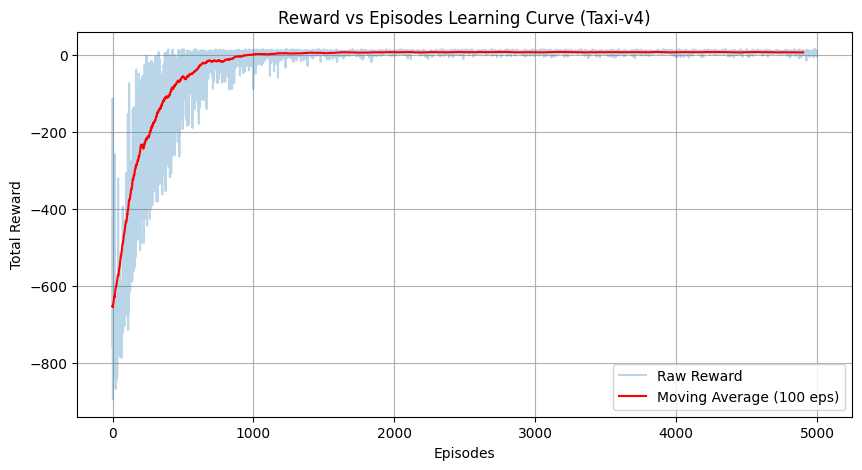

In [32]:
plt.figure(figsize=(10, 5))

# Calculate moving average to make graph smoother
window_size = 100
moving_avg = np.convolve(rewards_all_episodes, np.ones(window_size)/window_size, mode='valid')

plt.plot(rewards_all_episodes, alpha=0.3, label="Raw Reward")
plt.plot(moving_avg, color='red', label="Moving Average (100 eps)")
plt.title("Reward vs Episodes Learning Curve (Taxi-v4)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.savefig("learning_curve.png")
plt.show()

### Step 6: Demonstration (Test the Trained Agent)
We run 1 test episode with `epsilon = 0` (no random exploration) to see if the agent completes the task perfectly.

In [33]:
print("Testing Trained Agent...\n")

state, info = env.reset()
done = False
total_reward = 0
steps = 0

while not done:
    # Always exploit (no exploration)
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    steps += 1
    state = next_state

    if terminated or truncated:
        done = True

print(f"Test Episode Finished!")
print(f"Total Steps Taken: {steps}")
print(f"Total Reward: {total_reward}")
print("Agent successfully picked up and dropped off the passenger!" if total_reward > 0 else "Agent failed.")

Testing Trained Agent...

Test Episode Finished!
Total Steps Taken: 16
Total Reward: 5
Agent successfully picked up and dropped off the passenger!


### Conclusion
The Q-Learning agent successfully learned the optimal policy for the Taxi environment. The learning curve shows that the reward started highly negative (random moves) and gradually increased to positive values (efficient pickups and dropoffs). By decaying epsilon, the agent transitioned from exploration to exploitation, resulting in successful task completion.

### Step 7 — Final Performance Evaluation

Run this new cell after your existing training/testing code:

In [34]:
# Evaluate the trained agent over 100 episodes

test_episodes = 100

test_rewards = []
test_steps = []
successes = []

for episode in range(test_episodes):

    state, info = env.reset()
    total_reward = 0
    steps = 0
    success = False

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Choose best learned action
        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        state = next_state
        total_reward += reward
        steps += 1

        if reward == 20:
            success = True

    test_rewards.append(total_reward)
    test_steps.append(steps)
    successes.append(success)

print("===== FINAL PERFORMANCE =====")
print(f"Test Episodes       : {test_episodes}")
print(f"Average Reward      : {np.mean(test_rewards):.2f}")
print(f"Average Steps       : {np.mean(test_steps):.2f}")
print(f"Success Rate        : {np.mean(successes) * 100:.2f}%")
print(f"Best Reward         : {np.max(test_rewards)}")

===== FINAL PERFORMANCE =====
Test Episodes       : 100
Average Reward      : 7.89
Average Steps       : 13.11
Success Rate        : 100.00%
Best Reward         : 15
